# 02 — Baseline Models
**TrustGraph Credit Risk Project**

Trains LightGBM and Logistic Regression baselines, evaluates with AUC-ROC and KS statistic,
saves results to `data/processed/baseline_results.csv`, and plots ROC curves side-by-side.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_RAW   = ROOT / 'data' / 'raw'
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
DATA_FILE  = DATA_RAW / 'application_train.csv'

DATA_PROC.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"application_train.csv not found at {DATA_FILE}. "
        "Copy the file into data/raw/ and re-run this cell."
    )
print(f"Data file: {DATA_FILE}")

Data file: C:\Users\krish\Downloads\TrustGraph\data\raw\application_train.csv


## 1. Load data & separate TARGET

In [2]:
df = pd.read_csv(DATA_FILE)
print(f"Raw shape: {df.shape}")

y = df['TARGET']
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().to_string()}")

Raw shape: (307511, 122)
Features shape: (307511, 120)
Target distribution:
TARGET
0    282686
1     24825


## 2. Preprocessing — numeric median fill + label encode categoricals

In [3]:
# Identify column types
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}")

X_proc = X.copy()

# Fill numeric nulls with median
for col in num_cols:
    median_val = X_proc[col].median()
    X_proc[col] = X_proc[col].fillna(median_val)

# Label encode categoricals (fill missing with 'MISSING' first)
le = LabelEncoder()
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('MISSING')
    X_proc[col] = le.fit_transform(X_proc[col].astype(str))

print(f"Nulls remaining: {X_proc.isnull().sum().sum()}")
X_proc.head()

Numeric: 104, Categorical: 16


Nulls remaining: 0


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,7,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,1,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,7,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,7,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,7,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Train / test split (80/20 stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3%}  |  Test default rate: {y_test.mean():.3%}")

Train: (246008, 120), Test: (61503, 120)
Train default rate: 8.073%  |  Test default rate: 8.073%


## 4. Train LightGBM

In [5]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
print("LightGBM training complete.")

[100]	valid_0's binary_logloss: 0.576996


[200]	valid_0's binary_logloss: 0.562841


[300]	valid_0's binary_logloss: 0.553241


[400]	valid_0's binary_logloss: 0.54469


[500]	valid_0's binary_logloss: 0.537049
LightGBM training complete.


## 5. Train Logistic Regression

In [6]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lr.fit(X_train, y_train)
print("Logistic Regression training complete.")

Logistic Regression training complete.


## 6. Evaluate — AUC-ROC & KS statistic

In [7]:
def ks_statistic(y_true, y_prob):
    """KS statistic: max separation between CDFs of defaulters and non-defaulters."""
    pos_probs = y_prob[y_true == 1]
    neg_probs = y_prob[y_true == 0]
    ks_stat, _ = ks_2samp(pos_probs, neg_probs)
    return ks_stat

# Predict probabilities
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
lr_prob   = lr.predict_proba(X_test)[:, 1]

# Compute metrics
results = {
    'Model':       ['LightGBM', 'Logistic Regression'],
    'AUC_ROC':     [roc_auc_score(y_test, lgbm_prob), roc_auc_score(y_test, lr_prob)],
    'KS_Statistic':[ks_statistic(y_test.values, lgbm_prob), ks_statistic(y_test.values, lr_prob)],
}
results_df = pd.DataFrame(results)
results_df['AUC_ROC']      = results_df['AUC_ROC'].round(4)
results_df['KS_Statistic'] = results_df['KS_Statistic'].round(4)

print(results_df.to_string(index=False))

              Model  AUC_ROC  KS_Statistic
           LightGBM   0.7611        0.3908
Logistic Regression   0.6184        0.1750


## 7. Save comparison table

In [8]:
out_path = DATA_PROC / 'baseline_results.csv'
results_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
results_df

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\baseline_results.csv


,Model,AUC_ROC,KS_Statistic
0,LightGBM,0.7611,0.3908
1,Logistic Regression,0.6184,0.1750


## 8. ROC curves — side by side

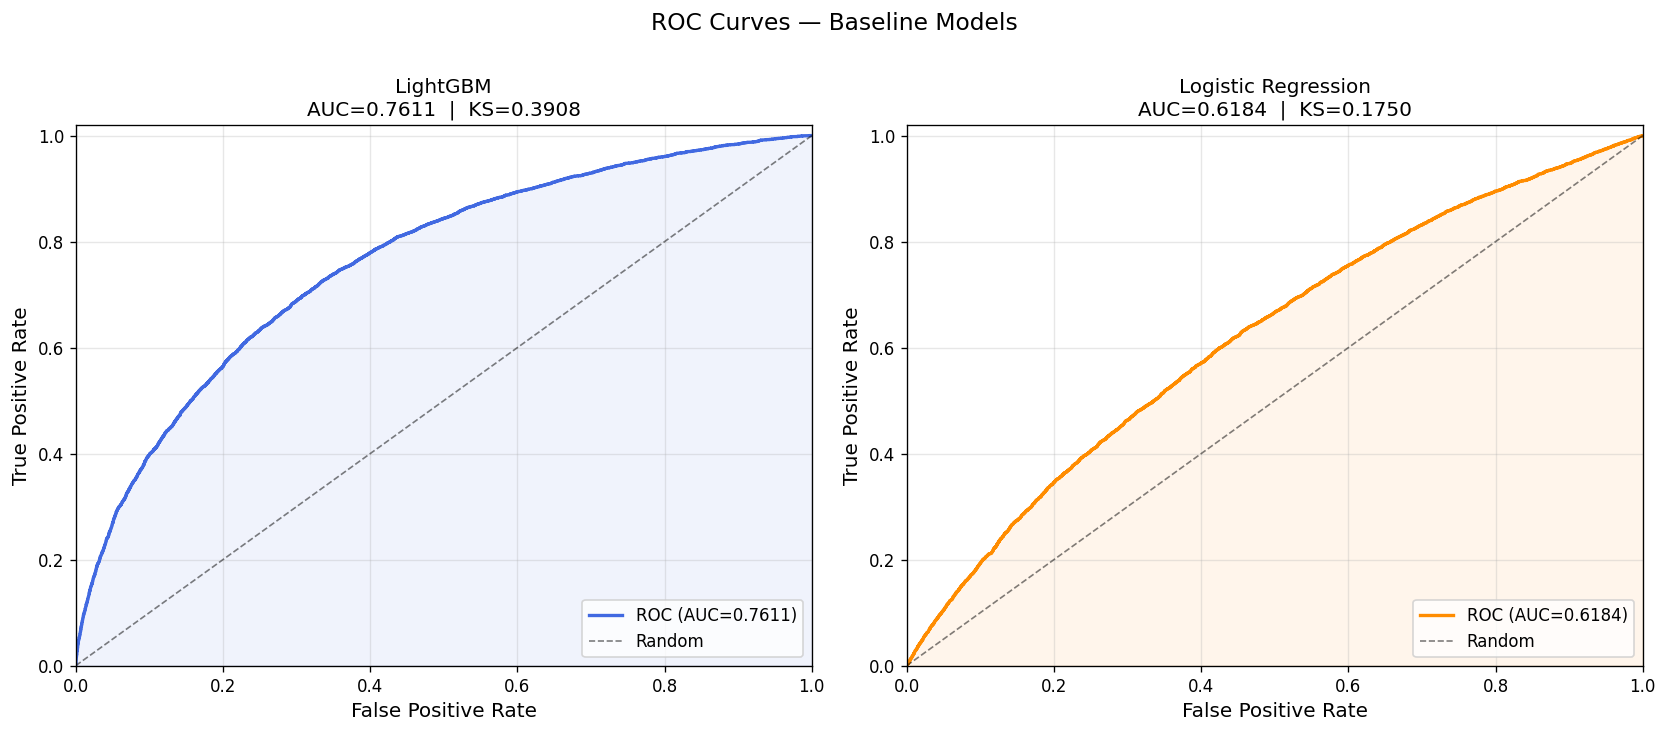

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\roc_curves_baseline.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_configs = [
    ('LightGBM',           lgbm_prob, 'royalblue'),
    ('Logistic Regression', lr_prob,   'darkorange'),
]

for ax, (name, probs, color) in zip(axes, model_configs):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score   = roc_auc_score(y_test, probs)
    ks_score    = ks_statistic(y_test.values, probs)

    ax.plot(fpr, tpr, color=color, lw=2, label=f'ROC (AUC={auc_score:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)

    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{name}\nAUC={auc_score:.4f}  |  KS={ks_score:.4f}', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — Baseline Models', fontsize=14, y=1.01)
plt.tight_layout()

roc_path = CHARTS_DIR / 'roc_curves_baseline.png'
plt.savefig(roc_path, bbox_inches='tight')
plt.show()
print(f"Saved: {roc_path}")

## Summary

| Output | Location |
|---|---|
| Comparison table | `data/processed/baseline_results.csv` |
| ROC curve plot | `data/processed/eda_charts/roc_curves_baseline.png` |